# 6 . Exposicion, CVA y portfolio: cierre de la bateria

Ultimo notebook de la bateria: combina el riesgo de UN trade frente a una contraparte
(perfil de exposicion EE/PFE, CVA unilateral y sus sensibilidades de credito) con una vision de
PORTFOLIO (`price_grid` sobre una cesta de opciones x escenarios de mercado). Para el IRS se usa
el camino nativo ya cableado (`ExpectedExposure`/`PFE95`/`UnilateralCVA`, medidas deterministas
sobre la curva de descuento); para una opcion (que SI tiene opcionalidad, fuera del ledger
deterministico) se usa `PayoffExposureProfileQ` y se integra el CVA a mano desde el perfil de
EE -- exactamente la formula que hay detras de `UnilateralCVA`, pero explicita.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "../../../build/clients/python")
sys.path.insert(0, "../src")

import math
import numpy as np
import matplotlib.pyplot as plt

import engine
import engine_typed as q
from engine_typed import greeks

print("modulo engine importado desde:", engine.__file__)


modulo engine importado desde: S:\Projects\engine_quant\clients\python\notebooks\../../../build/clients/python\engine.cp312-win_amd64.pyd


## 1. IRS frente a una contraparte: EE/PFE, CVA y sus sensibilidades de credito


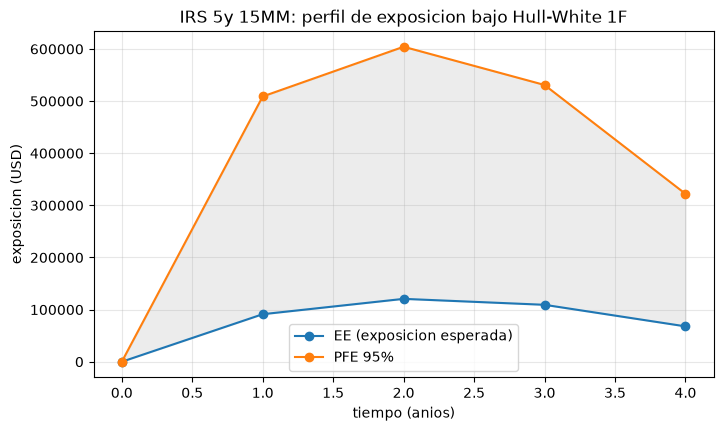

PV               =        169,936
UnilateralCVA    =          3,155
dCVA/dhazard_rate=        204,506  (subir 1 punto de hazard aumenta el CVA en esto)
dCVA/drecovery   =         -5,258  (mas recovery => menos CVA, signo negativo)


In [2]:
eng = engine.Engine()
hw_model = eng.create_model("HullWhite1F", {"a": 0.03, "b": 0.035, "sigma": 0.008, "r0": 0.032})
swap = q.IRSwap(
    notional=15_000_000.0, fixed_rate=0.036,
    payment_times=[1.0, 2.0, 3.0, 4.0, 5.0], accruals=[1.0] * 5,
)
swap_product = eng.create_product(swap.product_type, swap.to_params())
swap_market = engine.MarketSnapshot(
    pillars=[0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0], zero_rates=[0.031, 0.032, 0.034, 0.0355, 0.038, 0.0395, 0.0405],
    hazard_rate=0.015, recovery_rate=0.40,
)
swap_pricing = engine.PricingContext({"pricing_date": 0.0, "n_paths": 20_000.0, "n_steps": 52.0, "seed": 9.0})
execution = engine.ExecutionContext({"backend": "cpu"})

result = eng.price(swap_product, ["PV", "ExpectedExposure", "PFE95", "UnilateralCVA"], hw_model, swap_market, swap_pricing, execution)
ee, pfe, cva = result["ExpectedExposure"], result["PFE95"], result["UnilateralCVA"]
d_hazard = eng.price(swap_product, [greeks.hazard_rate().to_spec()], hw_model, swap_market, swap_pricing, execution)["Greek"].scalar
d_recovery = eng.price(swap_product, [greeks.recovery_rate().to_spec()], hw_model, swap_market, swap_pricing, execution)["Greek"].scalar

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ee.times, ee.primary, "o-", label="EE (exposicion esperada)")
ax.plot(pfe.times, pfe.primary, "o-", label="PFE 95%")
ax.fill_between(ee.times, ee.primary, pfe.primary, color="grey", alpha=0.15)
ax.set_xlabel("tiempo (anios)")
ax.set_ylabel("exposicion (USD)")
ax.set_title("IRS 5y 15MM: perfil de exposicion bajo Hull-White 1F")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f"PV               = {result['PV'].scalar:>14,.0f}")
print(f"UnilateralCVA    = {cva.scalar:>14,.0f}")
print(f"dCVA/dhazard_rate= {d_hazard:>14,.0f}  (subir 1 punto de hazard aumenta el CVA en esto)")
print(f"dCVA/drecovery   = {d_recovery:>14,.0f}  (mas recovery => menos CVA, signo negativo)")


## 2. Opcion frente a una contraparte: exposicion via Monte Carlo y CVA nativo

`PayoffExposureProfileQ` revalora el resto del payoff en cada fecha de `exposure_times`, en
las mismas trayectorias Monte Carlo -- el mismo insumo que consume `UnilateralCVA` por dentro
para el IRS. `PayoffUnilateralCvaQ` (medida nativa, Fase 5 de `PLAN_IMPROVE_NOTEBOOK.md`)
compone internamente ese mismo perfil EE con la formula
`CVA = (1-R) * sum_i EE_i * (S(t_{i-1}) - S(t_i)) * DF(t_i)` -- misma logica que ya usa
`UnilateralCvaMeasure` en C++ para el IRS, pero descontando por la curva observada de
`MarketSnapshot` en vez de la dinamica de un modelo de tipo corto (el `PayoffProduct` de abajo
vive bajo `GBM`, no bajo Hull-White). `hazard_rate`/`recovery_rate` se leen de ese mismo
`MarketSnapshot`, no de un parametro propio de la medida. El contrato de la call (aqui y en la
cesta de la seccion 3) se construye via `q.call_leg` (PLAN_IMPROVE_NOTEBOOK2.md Fase 6) en vez
de horneado a mano con `q.when`/`q.cashflow`/`q.maximum`.

> **Nota (`PLAN_IMPROVE_NOTEBOOK.md`, Fase 5):** la funcion `manual_cva` de abajo integraba a
> mano en Python exactamente la formula que `PayoffUnilateralCvaQ` ya resuelve en el motor --
> se conserva aqui como celda de verificacion cruzada explicita (compara contra la medida
> nativa en la celda siguiente, y ademas sirve para explorar un grid de hazard rate sin
> reconstruir un `MarketSnapshot` por punto), no como el unico camino.

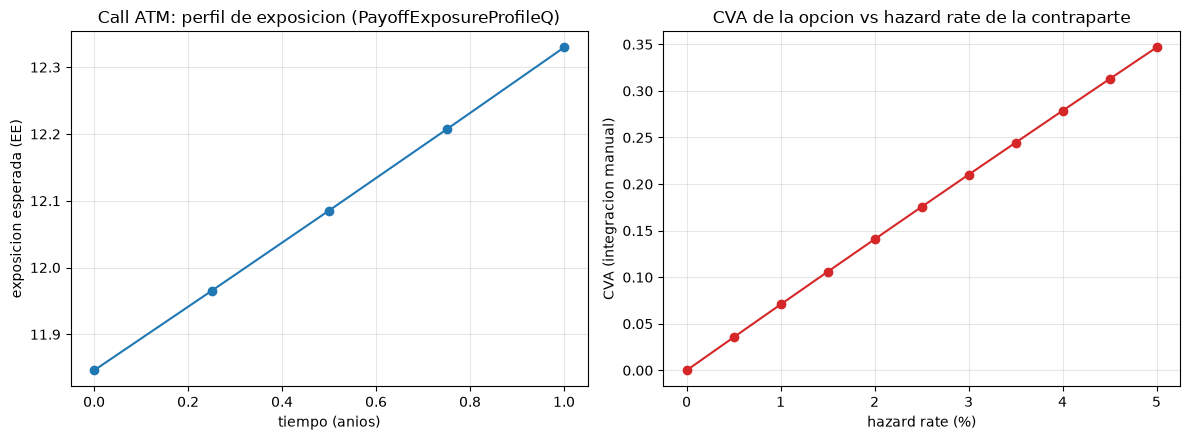

In [3]:
OBS = "EQ.SPOT.IDX"
S0, R_RATE, Q_DIV, SIGMA, T = 100.0, 0.04, 0.0, 0.25, 1.0
# q.call_leg (PLAN_IMPROVE_NOTEBOOK2.md Fase 6) en vez de horneado a mano con q.when/q.cashflow/q.maximum.
call_contract = q.call_leg(OBS, S0, 1.0, T)
call_product = eng.create_product("Payoff", q.PayoffProduct(id="OPT_CPTY", contract=call_contract).to_params())
option_model = eng.create_model("GBM", {"s0": S0, "r": R_RATE, "q": Q_DIV, "sigma": SIGMA, "observable": OBS})
# hazard_rate/recovery_rate fijados aqui (no en un grid) porque PayoffUnilateralCvaQ (celda
# siguiente) los lee de este MarketSnapshot -- el grid de mas abajo (hazard_grid) sigue
# explorando otros valores solo con manual_cva, que no necesita reconstruir el market.
HAZARD_FIXED, RECOVERY_FIXED = 0.02, 0.40
option_market = engine.MarketSnapshot(
    pillars=[T], zero_rates=[R_RATE], hazard_rate=HAZARD_FIXED, recovery_rate=RECOVERY_FIXED,
)
option_pricing = engine.PricingContext({"pricing_date": 0.0, "n_paths": 150_000.0, "n_steps": 1.0, "seed": 5.0})

exposure_times = [0.0, 0.25, 0.5, 0.75, 1.0]
exposure_result = eng.price(
    call_product, [("PayoffExposureProfileQ", {"exposure_times": exposure_times})],
    option_model, option_market, option_pricing, execution,
)["PayoffExposureProfileQ"]
ee_option = list(exposure_result.primary)


def manual_cva(ee_profile, times, hazard_rate, recovery, discount_rate):
    total = 0.0
    for i in range(1, len(times)):
        t0, t1 = times[i - 1], times[i]
        survival_prob = math.exp(-hazard_rate * t0) - math.exp(-hazard_rate * t1)
        discount = math.exp(-discount_rate * t1)
        total += (1.0 - recovery) * ee_profile[i] * survival_prob * discount
    return total


hazard_grid = np.arange(0.0, 0.051, 0.005)
cva_curve = [manual_cva(ee_option, exposure_times, float(h), 0.40, R_RATE) for h in hazard_grid]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(exposure_times, ee_option, "o-", color="tab:blue")
axes[0].set_xlabel("tiempo (anios)")
axes[0].set_ylabel("exposicion esperada (EE)")
axes[0].set_title("Call ATM: perfil de exposicion (PayoffExposureProfileQ)")
axes[0].grid(alpha=0.3)

axes[1].plot(hazard_grid * 100.0, cva_curve, "o-", color="tab:red")
axes[1].set_xlabel("hazard rate (%)")
axes[1].set_ylabel("CVA (integracion manual)")
axes[1].set_title("CVA de la opcion vs hazard rate de la contraparte")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# Fase 5 (PLAN_IMPROVE_NOTEBOOK.md): comparacion cruzada explicita entre la medida nativa
# y la integracion manual -- mismo perfil EE (misma PricingContext, mismas trayectorias),
# mismo hazard_rate/recovery_rate (los de option_market, fijados arriba).
native_cva_result = eng.price(
    call_product, [("PayoffUnilateralCvaQ", {"exposure_times": exposure_times})],
    option_model, option_market, option_pricing, execution,
)["PayoffUnilateralCvaQ"]
native_cva = native_cva_result.scalar
manual_cva_fixed = manual_cva(ee_option, exposure_times, HAZARD_FIXED, RECOVERY_FIXED, R_RATE)

print(f"PayoffUnilateralCvaQ (motor)      = {native_cva:,.6f}")
print(f"manual_cva (verificacion cruzada) = {manual_cva_fixed:,.6f}")
assert math.isclose(native_cva, manual_cva_fixed, rel_tol=1e-9, abs_tol=1e-9), (
    "PayoffUnilateralCvaQ diverge de la integracion manual -- se rompio la composicion "
    "PayoffExposureProfileQ + integracion de supervivencia (measure.cpp)"
)


PayoffUnilateralCvaQ (motor)      = 0.140741
manual_cva (verificacion cruzada) = 0.140741


## 3. Portfolio de opciones: PV bajo escenarios de mercado (`price_grid`)

Una cesta de calls a distintos strikes se revalora, en una sola rejilla, bajo dos escenarios
de volatilidad (base y estres) -- `price_grid` comparte la simulacion por cada combinacion
`(trade, model, market)`.


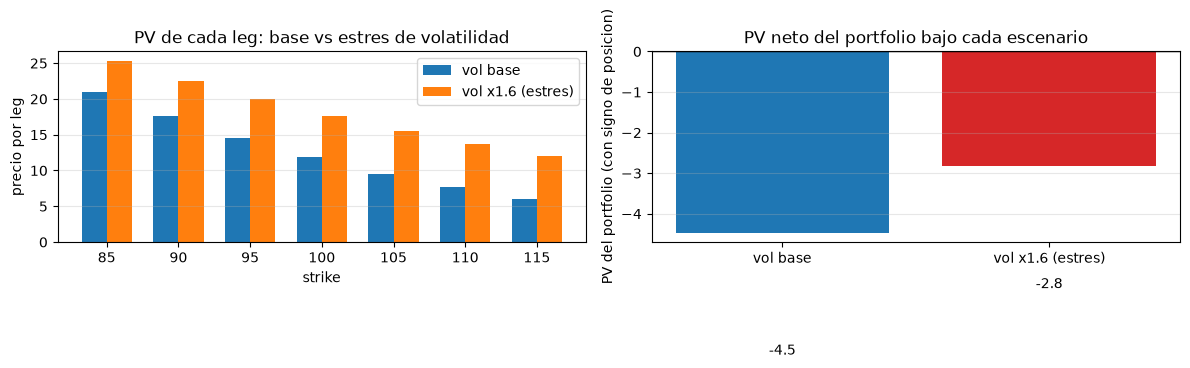

PV portfolio (base)   =      -4.47   delta neta =    0.008
PV portfolio (estres) =      -2.83   delta neta =   -0.007


In [5]:
strikes = np.array([85.0, 90.0, 95.0, 100.0, 105.0, 110.0, 115.0])
positions = np.array([-1.0, -1.0, 1.0, 2.0, 1.0, -1.0, -1.0])  # mariposa/condor ad-hoc, con signo

portfolio_products = []
for k in strikes:
    contract = q.call_leg(OBS, float(k), 1.0, T)  # PLAN_IMPROVE_NOTEBOOK2.md Fase 6
    portfolio_products.append(eng.create_product("Payoff", q.PayoffProduct(id=f"PORT_{k:.0f}", contract=contract).to_params()))

model_base = eng.create_model("GBM", {"s0": S0, "r": R_RATE, "q": Q_DIV, "sigma": SIGMA, "observable": OBS})
model_stress = eng.create_model("GBM", {"s0": S0, "r": R_RATE, "q": Q_DIV, "sigma": SIGMA * 1.6, "observable": OBS})

grid = eng.price_grid(
    portfolio_products, ["PayoffPriceQ", greeks.delta("PayoffPriceQ", "spot").to_spec()],
    [model_base, model_stress], [option_market], option_pricing, execution,
)

price_matrix = np.zeros((len(strikes), 2))
delta_matrix = np.zeros((len(strikes), 2))
for cell in grid:
    price_matrix[cell.trade_index, cell.model_index] = cell.measures["PayoffPriceQ"].scalar
    delta_matrix[cell.trade_index, cell.model_index] = cell.measures["Greek"].scalar

portfolio_pv = positions @ price_matrix
portfolio_delta = positions @ delta_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
width = 0.35
x = np.arange(len(strikes))
axes[0].bar(x - width / 2, price_matrix[:, 0], width, label="vol base")
axes[0].bar(x + width / 2, price_matrix[:, 1], width, label="vol x1.6 (estres)")
axes[0].set_xticks(x, [f"{k:.0f}" for k in strikes])
axes[0].set_xlabel("strike")
axes[0].set_ylabel("precio por leg")
axes[0].set_title("PV de cada leg: base vs estres de volatilidad")
axes[0].legend()
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(["vol base", "vol x1.6 (estres)"], portfolio_pv, color=["tab:blue", "tab:red"])
for i, v in enumerate(portfolio_pv):
    axes[1].text(i, v + (1 if v >= 0 else -3), f"{v:,.1f}", ha="center")
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set_ylabel("PV del portfolio (con signo de posicion)")
axes[1].set_title("PV neto del portfolio bajo cada escenario")
axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"PV portfolio (base)   = {portfolio_pv[0]:>10,.2f}   delta neta = {portfolio_delta[0]:>8,.3f}")
print(f"PV portfolio (estres) = {portfolio_pv[1]:>10,.2f}   delta neta = {portfolio_delta[1]:>8,.3f}")

## 4. Recapitulacion: todo lo que soporta el motor hoy


In [6]:
print("modelos disponibles: ", eng.list_models())
print("productos disponibles:", eng.list_products())
print("medidas disponibles: ", eng.list_measures())
print("calibradores disponibles:", eng.list_calibrators())


modelos disponibles:  ['HullWhite1F', 'HullWhite2F', 'GBM', 'GBM_P', 'GbmBasket']
productos disponibles: ['IRSwap', 'Payoff']
medidas disponibles:  ['ExposureProfile', 'DV01', 'UnilateralCVA', 'PayoffExposureProfileQ', 'PV', 'HullWhiteModelNpv', 'PayoffPriceQ', 'PayoffExerciseQ', 'PayoffHitProbabilityQ', 'PayoffUnilateralCvaQ', 'PayoffForecastP', 'PayoffHitProbabilityP', 'PayoffPnlDistributionP', 'PayoffSensitivityQ', 'Greek', 'PFE95', 'ExpectedExposure']
calibradores disponibles: ['HullWhite1F', 'HullWhite2F']
